# Bước 2 — Feature engineering: verify `features.parquet`

**Mục tiêu**: chạy `src.features.prepare_features()` (load_raw → clean → build_features → save) và kiểm tra từng feature mới có hợp lý không trước khi chuyển sang model.

Checklist cho từng feature:
1. `lead_time_days` + `lead_time_bucket` — phân phối khớp EDA, bucket counts hợp lý.
2. `dow`, `month`, `is_weekend` — value counts, basic sanity.
3. `is_holiday` — flag đúng các ngày lễ VN (Tết, 30/4, 2/9, ...).
4. `dow_sin/cos`, `month_sin/cos` — vẽ 2D scatter để xác nhận thật sự cyclic.
5. `occupancy_pct`, `available_pct` — distribution, không có ZeroDivision NaN bất ngờ.
6. `did_book` (label) — class balance, NA pattern.
7. Round-trip parquet — read back, schema giữ nguyên.

**Deliverable**: parquet sẵn sàng cho Bước 3 (forecast) và Bước 4 (demand).

## 1. Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 180)

## 2. Chạy pipeline `prepare_features`

`prepare_features()` gọi tuần tự: `load_raw()` → `clean()` (drop post-stay) → `build_features()` (thêm feature) → `save_features()` (ghi parquet).

Output mong đợi: ~46,480 rows (sau khi clean drop 15.84%), 27 cột (13 raw + 14 derived).

In [2]:
from src.features import prepare_features, DEFAULT_OUT

df = prepare_features()
print(f'shape : {df.shape}')
print(f'parquet: {DEFAULT_OUT} ({DEFAULT_OUT.stat().st_size/1024:.1f} KB)')
df.head(3)

shape : (337722, 27)
parquet: /Users/puppy/Desktop/AI-Course/projects/dynamic-pricing/data/processed/features.parquet (658.4 KB)


,updated_date,date,hotel_id,hotel_name,room_type_name,total_booked,total_maintenance,total,available,price,ota_price,room_type_segment,brand_sub_segment,lead_time_days,lead_time_bucket,dow,month,is_weekend,is_holiday,dow_sin,dow_cos,month_sin,month_cos,occupancy_pct,available_pct,next_total_booked,did_book
0,2024-11-26,2024-11-26,28,SIMV HBT,Deluxe with Balcony city view,4,0,4,0,3050000.0,13000000.0,High,Signature-HCM,0,same,1,11,0,0,0.781831,0.623490,-0.5,0.866025,1.0,0.0,NaN,<NA>
1,2024-11-26,2024-11-27,28,SIMV HBT,Deluxe with Balcony city view,4,0,4,0,3050000.0,13000000.0,High,Signature-HCM,1,same,2,11,0,0,0.974928,-0.222521,-0.5,0.866025,1.0,0.0,NaN,<NA>
2,2024-11-26,2024-11-28,28,SIMV HBT,Deluxe with Balcony city view,4,0,4,0,3050000.0,13000000.0,High,Signature-HCM,2,<1w,3,11,0,0,0.433884,-0.900969,-0.5,0.866025,1.0,0.0,NaN,<NA>


In [3]:
df.dtypes

updated_date         datetime64[ns]
date                 datetime64[ns]
hotel_id                      int64
hotel_name                   object
room_type_name               object
total_booked                  int64
total_maintenance             int64
total                         int64
available                     int64
price                       float64
ota_price                   float64
room_type_segment            object
brand_sub_segment            object
lead_time_days                int64
lead_time_bucket           category
dow                           int32
month                         int32
is_weekend                    int64
is_holiday                    int64
dow_sin                     float64
dow_cos                     float64
month_sin                   float64
month_cos                   float64
occupancy_pct               float64
available_pct               float64
next_total_booked           float64
did_book                      Int64
dtype: object

## 3. `lead_time_days` + `lead_time_bucket`

Sau `clean()`, `lead_time_days >= 0`. Bucket `>3m` ROADMAP định nghĩa là 90-365 ngày — vì max của dataset chỉ 90 ngày nên bucket này sẽ rỗng. Đây không phải bug — giữ bucket cho dataset tương lai dài hơn.

In [4]:
print('lead_time_days describe:')
print(df['lead_time_days'].describe())
print()
print('lead_time_bucket counts:')
print(df['lead_time_bucket'].value_counts().sort_index())

lead_time_days describe:
count    337722.000000
mean         37.687767
std          22.710741
min           0.000000
25%          18.000000
50%          37.000000
75%          56.000000
max          91.000000
Name: lead_time_days, dtype: float64

lead_time_bucket counts:
lead_time_bucket
same      8994
<1w      26986
<1m     103438
<3m     198270
>3m         34
Name: count, dtype: int64


In [5]:
# Sanity: bucket boundary đúng?
check = df.groupby('lead_time_bucket', observed=True)['lead_time_days'].agg(['min', 'max', 'count'])
print(check)

                  min  max   count
lead_time_bucket                  
same                0    1    8994
<1w                 2    7   26986
<1m                 8   30  103438
<3m                31   90  198270
>3m                91   91      34


## 4. Calendar: `dow`, `month`, `is_weekend`

Đếm theo dow để verify: 0=Mon ... 6=Sun. `is_weekend = 1` cho Sat (5) + Sun (6).

In [6]:
dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_check = df.groupby('dow').agg(rows=('dow', 'size'), is_weekend=('is_weekend', 'first'))
dow_check.index = [f'{i}={n}' for i, n in zip(dow_check.index, dow_names)]
print(dow_check)

print('\nmonth value counts:')
print(df['month'].value_counts().sort_index())

        rows  is_weekend
0=Mon  48529           0
1=Tue  48702           0
2=Wed  48158           0
3=Thu  48165           0
4=Fri  47770           0
5=Sat  48091           1
6=Sun  48307           1

month value counts:
month
1     29128
2     33278
3     44020
4     42465
5     41651
6     34839
7     24634
8     18011
9     16275
10    16709
11    16119
12    20593
Name: count, dtype: int64


## 5. `is_holiday` — verify đúng ngày lễ VN

List ra các stay_date được flag holiday để mắt thường check (Tết 2026 ~ 17/2, 30/4, 2/9, ...).

In [7]:
holiday_dates = (df.loc[df['is_holiday'] == 1, 'date']
                   .drop_duplicates().sort_values().reset_index(drop=True))
print(f'Số stay_date là holiday: {len(holiday_dates)}')
print('\nDanh sách:')
for d in holiday_dates:
    print(' ', d.strftime('%Y-%m-%d (%a)'))

Số stay_date là holiday: 22

Danh sách:
  2025-01-01 (Wed)
  2025-01-27 (Mon)
  2025-01-28 (Tue)
  2025-01-29 (Wed)
  2025-01-30 (Thu)
  2025-01-31 (Fri)
  2025-02-01 (Sat)
  2025-04-07 (Mon)
  2025-04-30 (Wed)
  2025-05-01 (Thu)
  2025-09-01 (Mon)
  2025-09-02 (Tue)
  2026-01-01 (Thu)
  2026-02-16 (Mon)
  2026-02-17 (Tue)
  2026-02-18 (Wed)
  2026-02-19 (Thu)
  2026-02-20 (Fri)
  2026-04-26 (Sun)
  2026-04-27 (Mon)
  2026-04-30 (Thu)
  2026-05-01 (Fri)


## 6. Cyclic encoding — verify sin/cos thật sự cyclic

Plot `(sin, cos)` ra 2D plane. Nếu encoding đúng → các điểm nằm trên đường tròn đơn vị, mỗi tháng/dow 1 điểm cách đều.

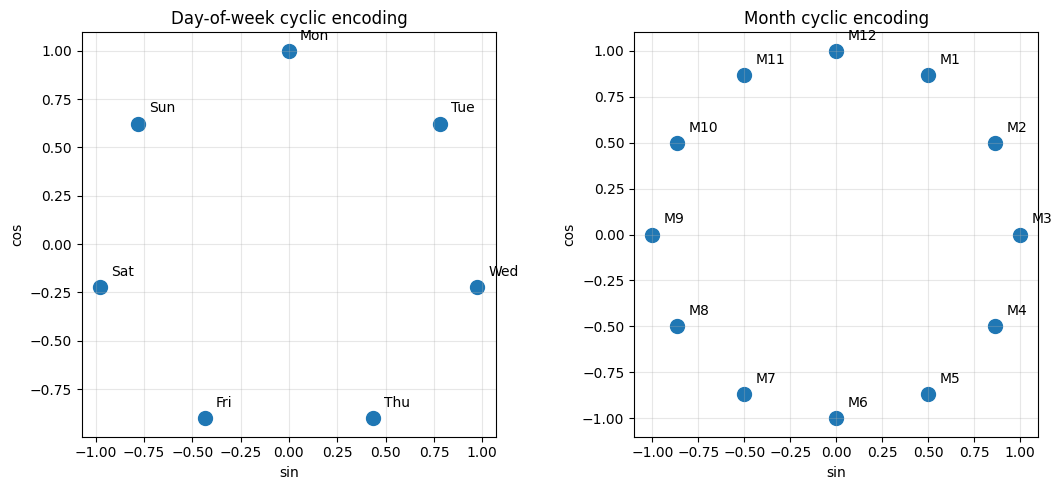

In [8]:
uniq_dow = df[['dow', 'dow_sin', 'dow_cos']].drop_duplicates().sort_values('dow')
uniq_month = df[['month', 'month_sin', 'month_cos']].drop_duplicates().sort_values('month')

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].scatter(uniq_dow['dow_sin'], uniq_dow['dow_cos'], s=100)
for _, r in uniq_dow.iterrows():
    axes[0].annotate(dow_names[int(r['dow'])],
                     (r['dow_sin'], r['dow_cos']),
                     textcoords='offset points', xytext=(8, 8))
axes[0].set_title('Day-of-week cyclic encoding')
axes[0].set_xlabel('sin'); axes[0].set_ylabel('cos')
axes[0].set_aspect('equal'); axes[0].grid(True, alpha=0.3)

axes[1].scatter(uniq_month['month_sin'], uniq_month['month_cos'], s=100)
for _, r in uniq_month.iterrows():
    axes[1].annotate(f"M{int(r['month'])}",
                     (r['month_sin'], r['month_cos']),
                     textcoords='offset points', xytext=(8, 8))
axes[1].set_title('Month cyclic encoding')
axes[1].set_xlabel('sin'); axes[1].set_ylabel('cos')
axes[1].set_aspect('equal'); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 7. Inventory ratios: `occupancy_pct`, `available_pct`

Phải nằm trong `[0, 1]`. Check không có NaN bất ngờ (do `total = 0` → safer với `np.where`).

In [9]:
print('occupancy_pct describe:')
print(df['occupancy_pct'].describe())
print(f"  NaN: {df['occupancy_pct'].isna().sum()}")
print('\navailable_pct describe:')
print(df['available_pct'].describe())
print(f"  NaN: {df['available_pct'].isna().sum()}")

# occupancy + maintenance% + available% nên ≈ 1 (sanity)
df_chk = df.copy()
df_chk['maintenance_pct'] = np.where(df_chk['total']>0, df_chk['total_maintenance']/df_chk['total'], 0)
df_chk['sum_pct'] = df_chk['occupancy_pct'] + df_chk['maintenance_pct'] + df_chk['available_pct']
print(f"\nSanity: occ+maint+avail nên ≈1.0 — mean={df_chk['sum_pct'].mean():.4f}, std={df_chk['sum_pct'].std():.4f}")

occupancy_pct describe:
count    337722.000000
mean          0.309998
std           0.379899
min           0.000000
25%           0.000000
50%           0.125000
75%           0.625000
max           1.250000
Name: occupancy_pct, dtype: float64
  NaN: 0

available_pct describe:
count    337722.000000
mean          0.684895
std           0.383097
min           0.000000
25%           0.375000
50%           0.875000
75%           1.000000
max           1.000000
Name: available_pct, dtype: float64
  NaN: 0

Sanity: occ+maint+avail nên ≈1.0 — mean=1.0000, std=0.0012


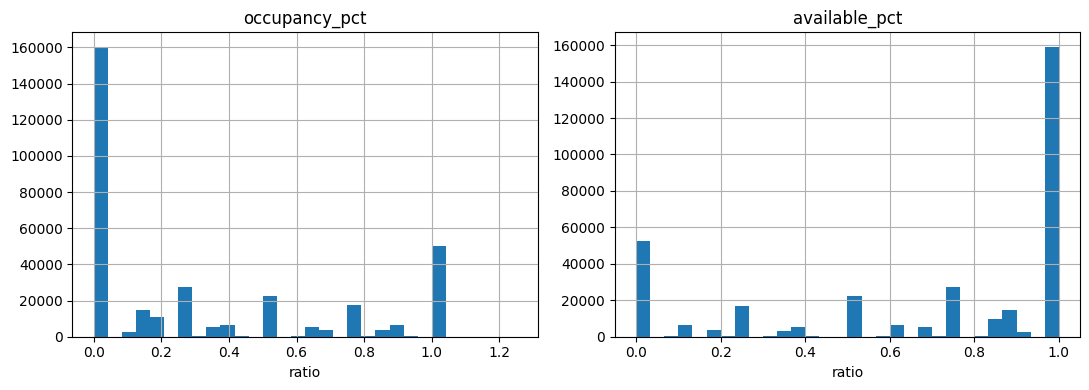

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df['occupancy_pct'].hist(bins=30, ax=axes[0])
axes[0].set_title('occupancy_pct'); axes[0].set_xlabel('ratio')
df['available_pct'].hist(bins=30, ax=axes[1])
axes[1].set_title('available_pct'); axes[1].set_xlabel('ratio')
plt.tight_layout(); plt.show()

## 8. Label `did_book` — class balance

**Logic**: với mỗi `(hotel, room_type, stay_date)`, so sánh snapshot hiện tại với snapshot kế tiếp (theo `updated_date`). Nếu `total_booked` tăng → `did_book = 1`. Snapshot CUỐI mỗi group không có "next" → `NA` (drop khi train).

Tỷ lệ positive thấp (~6%) là bình thường: phần lớn cặp snapshot không có booking xảy ra giữa. Bước 4 sẽ dùng `class_weight='balanced'` (LogReg) hoặc `is_unbalance=True` (LightGBM).

In [11]:
vc = df['did_book'].value_counts(dropna=False)
print('did_book counts:')
print(vc)

labeled = df.dropna(subset=['did_book'])
pos_rate = (labeled['did_book'] == 1).mean() * 100
print(f'\nPositive rate (loại NA): {pos_rate:.2f}%')

# Verify NA pattern: phải là dòng cuối mỗi group
na_rows = df[df['did_book'].isna()]
groups = df.groupby(['hotel_id', 'room_type_name', 'date']).size()
print(f'\nNA rows: {len(na_rows)} | n_groups (hotel,room,stay_date): {len(groups)}')
print('→ Phải bằng nhau nếu mỗi group có đúng 1 "snapshot cuối" → NA.')

did_book counts:
did_book
0       316630
1        15569
<NA>      5523
Name: count, dtype: Int64

Positive rate (loại NA): 4.69%

NA rows: 5523 | n_groups (hotel,room,stay_date): 5523
→ Phải bằng nhau nếu mỗi group có đúng 1 "snapshot cuối" → NA.


In [12]:
# Positive rate theo room_type — loại phòng nào "hot"?
print(labeled.groupby('room_type_name')['did_book']
             .agg(events='sum', total='count', rate='mean')
             .round(3)
             .sort_values('rate', ascending=False))

                                         events  total   rate
room_type_name                                               
Superior City View                          967   9086  0.106
Deluxe with banquette seating               751   9086  0.083
Deluxe with balcony                        2967  41141  0.072
Studio with balcony                        2382  39963   0.06
Studio                                     2317  41145  0.056
Studio City View                           2247  41138  0.055
Deluxe City View Room                       493   9086  0.054
Deluxe City View with banquette seating     456   9086   0.05
Premier city view                           419   9086  0.046
Deluxe with Balcony city view              1692  41139  0.041
Junior Suite                                501  41105  0.012
Grand Suite                                 377  41138  0.009


## 9. Round-trip parquet

Read lại file vừa save → verify schema/dtypes giữ nguyên (đặc biệt `lead_time_bucket` là Categorical và `did_book` là `Int64` nullable).

In [13]:
df2 = pd.read_parquet(DEFAULT_OUT)
print(f'read shape: {df2.shape}')
print(f'\nlead_time_bucket dtype: {df2["lead_time_bucket"].dtype}')
print(f'did_book dtype        : {df2["did_book"].dtype}')
print(f'\nMatches in-memory df? {df2.shape == df.shape}')

read shape: (337722, 27)

lead_time_bucket dtype: category
did_book dtype        : Int64

Matches in-memory df? True


## 10. Insights cho Bước 3 (Forecast)

Features đã sẵn sàng. Lưu ý cho Bước 3:

- **Target SARIMA**: `price` (direct), latest snapshot per stay_date — convention từ EDA Section 7.
- **Exog cho SARIMAX**: `is_holiday`, `is_weekend`, `dow_sin`, `dow_cos`, `month_sin`, `month_cos`. KHÔNG dùng `occupancy_pct` / `available_pct` vì future values unknown khi forecast.
- **5 series cần fit**: 1 model per `(hotel_id, room_type_name)`, mỗi series có 211 stay_dates → dư xài cho `auto_arima` với weekly seasonality `m=7`.
- **Hold-out**: 30 ngày cuối (theo ROADMAP §3 Bước 3).

**Lưu ý cho Bước 4 (Demand)**:
- Training set: drop rows `did_book.isna()` (snapshot cuối mỗi group).
- Class imbalance 6.79% → cần `class_weight='balanced'` hoặc `is_unbalance=True`.
- Features cho LogReg/LightGBM: `price`, `occupancy_pct`, `available_pct`, `lead_time_days`, `dow`, `is_weekend`, `is_holiday`, `room_type_segment` (one-hot).